In [1]:
# ============================================================================
# COLAB SETUP
# ============================================================================
import os, sys, time, json, pickle, random, subprocess
from pathlib import Path

# --- 1. Монтируем Google Drive ---
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT = Path('/content/drive/MyDrive/cifar10_runs')
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)

RUNS_DIR      = DRIVE_ROOT / 'runs'          # финальные артефакты
CKPT_DIR      = DRIVE_ROOT / 'checkpoints'   # промежуточные чекпоинты
DATA_ROOT     = DRIVE_ROOT / 'data'          # CIFAR-10 + кэши
RUNS_DIR.mkdir(exist_ok=True)
CKPT_DIR.mkdir(exist_ok=True)
DATA_ROOT.mkdir(exist_ok=True)

print("DRIVE_ROOT =", DRIVE_ROOT)

# --- 2. Зависимости ---
# torch/torchvision в Colab уже стоят; проверяем/ставим остальное
def _ensure(pkg, import_name=None):
    import_name = import_name or pkg
    try:
        __import__(import_name)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                       check=True)

_ensure("torcheval", "torcheval")
_ensure("tqdm", "tqdm")

# --- 3. Проверяем GPU ---
!nvidia-smi
import torch
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))
    free, total = torch.cuda.mem_get_info()
    print(f"VRAM: {free/1e9:.2f} free / {total/1e9:.2f} GB total")

# --- 4. Anti-idle (опционально): не даём Colab заснуть ---
# Раскомментируй, если планируешь долгие сессии без взаимодействия.
# from IPython.display import display, Javascript
# display(Javascript('''
# function ClickConnect(){
#     console.log("keep-alive");
#     document.querySelector("colab-connect-button").click()
# }
# setInterval(ClickConnect, 60000)
# '''))

Mounted at /content/drive
DRIVE_ROOT = /content/drive/MyDrive/cifar10_runs
Tue Sep 15 17:26:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                      

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from PIL import Image, ImageFilter

from sklearn.model_selection import train_test_split
from torcheval.metrics.functional import multiclass_f1_score
from tqdm.auto import tqdm


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

NUM_CLASSES      = 10
SEED             = 42
CORRUPTION_SEED  = 0
NUM_WORKERS      = 2                # В Colab T4 / 2 vCPU — 2 рабочих процесса
PIN_MEMORY       = torch.cuda.is_available()

# Бюджет на одну Colab-сессию. Как только превышен — обучение останавливается
# и сохраняет чекпоинт, чтобы можно было продолжить в следующей сессии.
SESSION_BUDGET_SEC = 10 * 3600      # 10 часов, чтобы не ловить 12-часовой обрыв
SESSION_START_TS   = time.time()


def session_time_left():
    return SESSION_BUDGET_SEC - (time.time() - SESSION_START_TS)


def make_scaler(enabled: bool):
    try:
        return torch.amp.GradScaler('cuda', enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)

Используется устройство: cuda


In [3]:
cifar_train = torchvision.datasets.CIFAR10(
    root=str(DATA_ROOT),
    train=True,
    download=True,
    transform=None,
)

X_all = cifar_train.data.astype('float32') / 255.0
y_all = np.array(cifar_train.targets, dtype='int64')
cifar_classes = cifar_train.classes

print(f"X shape: {X_all.shape}, y shape: {y_all.shape}")

X_train_part, X_val, y_train_part, y_val = train_test_split(
    X_all, y_all,
    test_size=0.1,
    random_state=SEED,
    stratify=y_all,
)

100%|██████████| 170M/170M [41:19<00:00, 68.8kB/s]


X shape: (50000, 32, 32, 3), y shape: (50000,)


In [4]:
class CIFAR10ArrayDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = Image.fromarray((self.images[index] * 255).astype('uint8'))
        label = int(self.labels[index])
        if self.transform is not None:
            image = self.transform(image)
        return image, label


cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std  = (0.2470, 0.2435, 0.2616)

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])
cifar_mean_t = torch.tensor(cifar_mean).view(1, 3, 1, 1)
cifar_std_t  = torch.tensor(cifar_std).view(1, 3, 1, 1)


def make_transforms(aug_kind):
    if aug_kind == "none":
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(cifar_mean, cifar_std),
        ])
    if aug_kind == "crop_flip":
        return transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(0.5),
            transforms.ToTensor(),
            transforms.Normalize(cifar_mean, cifar_std),
        ])
    if aug_kind == "crop_flip_color":
        return transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(0.5),
            transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
            transforms.ToTensor(),
            transforms.Normalize(cifar_mean, cifar_std),
        ])
    if aug_kind == "crop_flip_rot":
        return transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            transforms.Normalize(cifar_mean, cifar_std),
        ])
    if aug_kind == "crop_flip_erase":
        return transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(0.5),
            transforms.ToTensor(),
            transforms.Normalize(cifar_mean, cifar_std),
            transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), value=0.0),
        ])
    raise ValueError(f"Unknown aug_kind: {aug_kind}")


def make_transforms_stable():
    return transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(0.5),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(cifar_mean, cifar_std),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), value=0.0),
    ])


def _get_rng(rng):
    return rng if rng is not None else np.random.default_rng(0)


def c_gaussian_noise(x, sev, rng=None):
    rng = _get_rng(rng)
    std = [0.04, 0.08, 0.12, 0.16, 0.20][sev]
    return np.clip(x + rng.standard_normal(x.shape).astype('float32') * std, 0, 1)


def c_gaussian_blur(x, sev, rng=None):
    radius = [0.5, 1.0, 1.5, 2.0, 2.5][sev]
    out = np.stack([
        np.array(Image.fromarray((img * 255).astype('uint8'))
                 .filter(ImageFilter.GaussianBlur(radius)))
        for img in x
    ])
    return out.astype('float32') / 255.0


def c_brightness(x, sev, rng=None):
    factor = [1.3, 1.5, 1.8, 2.1, 2.4][sev]
    return np.clip(x * factor, 0, 1)


def c_contrast(x, sev, rng=None):
    factor = [0.8, 0.6, 0.5, 0.4, 0.3][sev]
    mean = x.mean(axis=(1, 2, 3), keepdims=True)
    return np.clip((x - mean) * factor + mean, 0, 1)


def c_pixelate(x, sev, rng=None):
    size = [24, 20, 16, 12, 8][sev]
    out = []
    for img in x:
        p = (Image.fromarray((img * 255).astype('uint8'))
             .resize((size, size), Image.BILINEAR)
             .resize((32, 32), Image.NEAREST))
        out.append(np.array(p))
    return np.stack(out).astype('float32') / 255.0


CORRUPTIONS = {
    "noise":      c_gaussian_noise,
    "blur":       c_gaussian_blur,
    "brightness": c_brightness,
    "contrast":   c_contrast,
    "pixelate":   c_pixelate,
}

In [5]:
class CIFAR10_CNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=0)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=0)
        self.bn2 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, 64)
        self.fc3 = nn.Linear(64, num_classes)
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        return self.fc3(x)

In [6]:
# ============================================================================
# Utilities
# ============================================================================
def _capture_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


def _set_frozen_bn_eval(model, prefix="features."):
    for name, m in model.named_modules():
        if isinstance(m, nn.modules.batchnorm._BatchNorm) \
                and name.startswith(prefix):
            m.eval()


def _save_ckpt(path, *, epoch, model, optimizer, scheduler, scaler,
               best_acc, best_state, history):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler else None,
        "scaler_state": scaler.state_dict() if scaler else None,
        "best_acc": best_acc,
        "best_state": best_state,
        "history": history,
    }, tmp)
    tmp.replace(path)   # атомарная замена


def _try_resume(path, *, model, optimizer, scheduler, scaler):
    path = Path(path)
    if not path.exists():
        return None
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
    if scaler is not None and ckpt.get("scaler_state") is not None:
        scaler.load_state_dict(ckpt["scaler_state"])
    return ckpt


# ============================================================================
# Resumable _fit
# ============================================================================
def _fit(model, tr, va, criterion, optimizer, scheduler, epochs, device,
         tag="", keep_frozen_bn_eval=False, scaler=None,
         warmup_epochs=0, accum_steps=1, verbose=True,
         ckpt_path=None, resume=True, session_budget_sec=None):
    """
    Полностью resumable цикл обучения.

    - Сохраняет чекпоинт после каждой эпохи в ckpt_path (на Drive).
    - При resume=True и наличии чекпоинта восстанавливает состояние и
      продолжает с последней незавершённой эпохи.
    - Если session_budget_sec задан и время сессии вышло — обучение
      останавливается и чекпоинт сохраняется.
    - По завершении загружает best_state.
    """
    is_cuda = device.type == 'cuda'
    if is_cuda:
        model = model.to(memory_format=torch.channels_last)

    base_lrs = [g['lr'] for g in optimizer.param_groups]
    history = {"tl": [], "vl": [], "ta": [], "va": []}
    best_acc, best_state = -1.0, _capture_state(model)
    start_epoch = 0

    if ckpt_path is not None and resume:
        ckpt = _try_resume(ckpt_path, model=model, optimizer=optimizer,
                           scheduler=scheduler, scaler=scaler)
        if ckpt is not None:
            start_epoch = ckpt["epoch"] + 1
            best_acc   = ckpt.get("best_acc", -1.0)
            best_state = ckpt.get("best_state", best_state)
            history    = ckpt.get("history", history)
            print(f"  [{tag}] resumed from epoch {start_epoch} "
                  f"(best_acc so far = {best_acc:.4f})")
        if start_epoch >= epochs:
            print(f"  [{tag}] already finished ({start_epoch}/{epochs}). "
                  f"Loading best_state.")
            model.load_state_dict(best_state)
            return best_acc, best_state, history

    session_t0 = time.time()

    for ep in range(start_epoch, epochs):
        # ---------- session budget ----------
        if session_budget_sec is not None:
            elapsed_session = time.time() - session_t0
            if elapsed_session > session_budget_sec and ep > start_epoch:
                print(f"  [{tag}] session budget reached at ep {ep}. "
                      f"Saving checkpoint and stopping.")
                _save_ckpt(ckpt_path, epoch=ep - 1, model=model,
                           optimizer=optimizer, scheduler=scheduler,
                           scaler=scaler, best_acc=best_acc,
                           best_state=best_state, history=history)
                model.load_state_dict(best_state)
                return best_acc, best_state, history

        # ---------- warmup ----------
        if ep < warmup_epochs:
            factor = float(ep + 1) / float(warmup_epochs)
            for g, blr in zip(optimizer.param_groups, base_lrs):
                g['lr'] = blr * factor
        cur_lr = optimizer.param_groups[-1]['lr']

        # ---------- train ----------
        model.train()
        if keep_frozen_bn_eval:
            _set_frozen_bn_eval(model, prefix="features.")

        total_loss, correct, total = 0.0, 0, 0
        accum_counter = 0
        optimizer.zero_grad(set_to_none=True)

        pbar = tqdm(tr, desc=f"[{tag}] ep {ep+1:2d}/{epochs} train",
                    leave=False, dynamic_ncols=True, mininterval=1.0)
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if is_cuda:
                images = images.to(memory_format=torch.channels_last)

            if scaler is not None:
                with torch.autocast(device_type=device.type,
                                    dtype=torch.float16, enabled=is_cuda):
                    outputs = model(images)
                    loss_raw = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss_raw = criterion(outputs, labels)

            if not torch.isfinite(loss_raw):
                continue

            loss = loss_raw / accum_steps
            if scaler is not None:
                scaler.scale(loss).backward()
            else:
                loss.backward()
            accum_counter += 1

            if accum_counter % accum_steps == 0:
                if scaler is not None:
                    scaler.step(optimizer); scaler.update()
                else:
                    optimizer.step()
                optimizer.zero_grad(set_to_none=True)

            total_loss += loss_raw.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({
                "loss": f"{total_loss / max(total, 1):.4f}",
                "acc":  f"{correct / max(total, 1):.4f}",
                "lr":   f"{cur_lr:.2e}",
            })

        if accum_counter > 0 and accum_counter % accum_steps != 0:
            if scaler is not None:
                scaler.step(optimizer); scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        tl = total_loss / max(total, 1)
        ta = correct / max(total, 1)

        # ---------- validate ----------
        model.eval()
        vl, va_, n = 0.0, 0, 0
        with torch.inference_mode():
            for images, labels in va:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                if is_cuda:
                    images = images.to(memory_format=torch.channels_last)
                if scaler is not None:
                    with torch.autocast(device_type=device.type,
                                        dtype=torch.float16, enabled=is_cuda):
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                vl += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                n += labels.size(0)
                va_ += predicted.eq(labels).sum().item()
        vl = vl / max(n, 1)
        va_ = va_ / max(n, 1)

        if scheduler is not None and ep >= warmup_epochs:
            scheduler.step(vl)

        history["tl"].append(tl); history["ta"].append(ta)
        history["vl"].append(vl); history["va"].append(va_)

        marker = ""
        if va_ > best_acc:
            best_acc = va_
            best_state = _capture_state(model)
            marker = " *best*"

        print(f"  [{tag}] ep {ep+1:2d}/{epochs} | "
              f"tl={tl:.4f} ta={ta:.4f} | "
              f"vl={vl:.4f} va={va_:.4f} | lr={cur_lr:.2e}{marker}")

        # ---------- checkpoint ----------
        if ckpt_path is not None:
            _save_ckpt(ckpt_path, epoch=ep, model=model,
                       optimizer=optimizer, scheduler=scheduler,
                       scaler=scaler, best_acc=best_acc,
                       best_state=best_state, history=history)

    model.load_state_dict(best_state)
    print(f"  [{tag}] best val acc = {best_acc:.4f}")
    return best_acc, best_state, history

In [7]:
def make_loaders(aug_kind, X_tr, y_tr, X_v, y_v, batch_size=512):
    tr_ds = CIFAR10ArrayDataset(X_tr, y_tr, transform=make_transforms(aug_kind))
    va_ds = CIFAR10ArrayDataset(X_v, y_v, transform=val_transform)
    tr = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                    persistent_workers=NUM_WORKERS > 0)
    va = DataLoader(va_ds, batch_size=batch_size, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                    persistent_workers=NUM_WORKERS > 0)
    return tr, va


def make_loaders_stable(X_tr, y_tr, X_v, y_v, batch_size=512):
    tr_ds = CIFAR10ArrayDataset(X_tr, y_tr, transform=make_transforms_stable())
    va_ds = CIFAR10ArrayDataset(X_v, y_v, transform=val_transform)
    tr = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                    persistent_workers=NUM_WORKERS > 0)
    va = DataLoader(va_ds, batch_size=batch_size, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                    persistent_workers=NUM_WORKERS > 0)
    return tr, va


def train_model(aug_kind, X_tr, y_tr, X_v, y_v,
                epochs=15, weight_decay=0.0,
                label_smoothing=0.0, seed=SEED, verbose=False,
                resume=True, session_budget_sec=None):
    torch.manual_seed(seed); np.random.seed(seed)
    tr, va = make_loaders(aug_kind, X_tr, y_tr, X_v, y_v)
    model = CIFAR10_CNN(num_classes=NUM_CLASSES).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.Adam(model.parameters(), lr=1e-3,
                           weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

    ckpt_path = CKPT_DIR / f"cnn_{aug_kind}.pt"
    _fit(model, tr, va, criterion, optimizer, scheduler,
         epochs=epochs, device=device, tag=aug_kind, verbose=verbose,
         ckpt_path=ckpt_path, resume=resume,
         session_budget_sec=session_budget_sec)
    return model


def train_stable(X_tr, y_tr, X_v, y_v, epochs=40, weight_decay=5e-4,
                 label_smoothing=0.1, seed=SEED,
                 resume=True, session_budget_sec=None):
    torch.manual_seed(seed); np.random.seed(seed)
    tr, va = make_loaders_stable(X_tr, y_tr, X_v, y_v)
    model = CIFAR10_CNN(num_classes=NUM_CLASSES).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.Adam(model.parameters(), lr=1e-3,
                           weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

    ckpt_path = CKPT_DIR / "cnn_stable.pt"
    _, _, hist = _fit(model, tr, va, criterion, optimizer, scheduler,
                      epochs=epochs, device=device, tag="stable",
                      verbose=True, ckpt_path=ckpt_path, resume=resume,
                      session_budget_sec=session_budget_sec)
    return model, hist


def finetune_from(model_base, X_tr, y_tr, X_v, y_v,
                  epochs=20, weight_decay=5e-4, lr=3e-4, seed=SEED,
                  resume=True, session_budget_sec=None):
    torch.manual_seed(seed); np.random.seed(seed)
    tr, va = make_loaders_stable(X_tr, y_tr, X_v, y_v)

    model = CIFAR10_CNN(num_classes=NUM_CLASSES).to(device)
    model.load_state_dict(model_base.state_dict())

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

    ckpt_path = CKPT_DIR / "cnn_finetune.pt"
    _fit(model, tr, va, criterion, optimizer, scheduler,
         epochs=epochs, device=device, tag="ft", verbose=True,
         ckpt_path=ckpt_path, resume=resume,
         session_budget_sec=session_budget_sec)
    return model

In [8]:
@torch.inference_mode()
def evaluate_numpy(model, X_np, y_np, batch_size=512, use_amp=True):
    model.eval()
    md = next(model.parameters()).device
    is_cuda = md.type == 'cuda'
    if is_cuda:
        model = model.to(memory_format=torch.channels_last)

    X = torch.from_numpy(X_np).permute(0, 3, 1, 2).float()
    X = (X - cifar_mean_t) / cifar_std_t
    y = torch.from_numpy(y_np).long()

    preds = []
    for i in range(0, len(X), batch_size):
        b = X[i:i + batch_size].to(md, non_blocking=True)
        if is_cuda:
            b = b.to(memory_format=torch.channels_last)
            with torch.autocast(device_type='cuda', dtype=torch.float16,
                                enabled=use_amp):
                logits = model(b)
        else:
            logits = model(b)
        preds.append(logits.argmax(1).cpu())
    preds = torch.cat(preds)
    acc = (preds == y).float().mean().item()
    f1 = multiclass_f1_score(preds, y, num_classes=NUM_CLASSES,
                             average="macro").item()
    return acc, f1


@torch.inference_mode()
def evaluate_cached(model, tensor, y_np, batch_size=128, use_amp=True):
    model.eval()
    md = next(model.parameters()).device
    is_cuda = md.type == 'cuda'
    if is_cuda:
        model = model.to(memory_format=torch.channels_last)

    y = torch.from_numpy(y_np).long()
    preds = []
    for i in range(0, len(tensor), batch_size):
        b = tensor[i:i + batch_size]
        if not is_cuda:
            b = b.float()
        b = b.to(md, non_blocking=True)
        if is_cuda:
            b = b.to(memory_format=torch.channels_last)
            with torch.autocast(device_type='cuda', dtype=torch.float16,
                                enabled=use_amp):
                logits = model(b)
        else:
            logits = model(b)
        preds.append(logits.argmax(1).cpu())
    preds = torch.cat(preds)
    acc = (preds == y).float().mean().item()
    f1 = multiclass_f1_score(preds, y, num_classes=NUM_CLASSES,
                             average="macro").item()
    return acc, f1


CACHE_DTYPE = torch.float16


def _transform_to_tensor(X_np, transform, chunk=256, dtype=torch.float16):
    out = []
    for i in range(0, len(X_np), chunk):
        part = X_np[i:i + chunk]
        batch = torch.stack([
            transform(Image.fromarray((img * 255).astype('uint8')))
            for img in part
        ])
        if dtype is not None:
            batch = batch.to(dtype)
        out.append(batch)
    return torch.cat(out)


def build_corrupted_cache(X_val, y_val, transform, severities=(1, 3, 5),
                          max_samples=None, dtype=CACHE_DTYPE,
                          seed=SEED, corruption_seed=CORRUPTION_SEED,
                          verbose=True):
    if max_samples is not None and max_samples < len(X_val):
        idx = np.random.default_rng(seed).choice(
            len(X_val), max_samples, replace=False)
        X_val = X_val[idx]
        y_sub = y_val[idx]
    else:
        y_sub = y_val

    rng = np.random.default_rng(corruption_seed)
    cache = {"clean": _transform_to_tensor(X_val, transform, dtype=dtype)}
    tasks = [(n, s) for n in CORRUPTIONS for s in severities]
    for name, sev in tqdm(tasks, desc="building cache", leave=False):
        cache[(name, sev)] = _transform_to_tensor(
            CORRUPTIONS[name](X_val.copy(), sev - 1, rng=rng),
            transform, dtype=dtype)
    if verbose:
        mb = sum(v.numel() * v.element_size() for v in cache.values()) / 1e6
        print(f"  cache: {len(cache)} наборов, ~{mb:.0f} MB, "
              f"y_subset={len(y_sub)}")
    return cache, y_sub


def robustness_report_cached(model, cache, y_sub, batch_size=128, tag="eval"):
    items = list(cache.items())
    out = {}
    for k, v in tqdm(items, desc=f"[{tag}] robustness", leave=False):
        out[k] = evaluate_cached(model, v, y_sub, batch_size=batch_size)
    return out


def summarize(report, tag):
    clean = report["clean"]
    cor = [v for k, v in report.items() if isinstance(k, tuple)]
    acc_c = np.mean([v[0] for v in cor])
    f1_c  = np.mean([v[1] for v in cor])
    print(f"{tag:14s} | clean acc={clean[0]:.3f} f1={clean[1]:.3f} "
          f"| corrupted acc={acc_c:.3f} f1={f1_c:.3f}")


def save_experiment(run_name, *, config,
                    frozen_model=None, full_model=None,
                    report_frozen=None, report_full=None,
                    history_frozen=None, history_full=None):
    d = RUNS_DIR / run_name
    d.mkdir(parents=True, exist_ok=True)
    if frozen_model is not None:
        torch.save(frozen_model.state_dict(), d / "frozen.pt")
    if full_model is not None:
        torch.save(full_model.state_dict(), d / "full.pt")
    if report_frozen is not None:
        with open(d / "report_frozen.pkl", "wb") as f:
            pickle.dump(report_frozen, f)
    if report_full is not None:
        with open(d / "report_full.pkl", "wb") as f:
            pickle.dump(report_full, f)
    if history_frozen is not None:
        with open(d / "history_frozen.pkl", "wb") as f:
            pickle.dump(history_frozen, f)
    if history_full is not None:
        with open(d / "history_full.pkl", "wb") as f:
            pickle.dump(history_full, f)
    meta = {"config": config, "saved_at": time.strftime("%Y-%m-%d %H:%M:%S")}
    with open(d / "config.json", "w") as f:
        json.dump(meta, f, indent=2, default=str)
    print(f"[save] {d} -> {sorted(p.name for p in d.iterdir())}")


def load_reports(run_name):
    d = RUNS_DIR / run_name
    out = {}
    for name in ("report_frozen", "report_full",
                 "history_frozen", "history_full"):
        p = d / f"{name}.pkl"
        if p.exists():
            with open(p, "rb") as f:
                out[name] = pickle.load(f)
    if (d / "config.json").exists():
        with open(d / "config.json") as f:
            out["meta"] = json.load(f)
    return out

In [19]:
import functools
from torch.utils.checkpoint import checkpoint_sequential
import torchvision.models as models
from torchvision.models import (
    EfficientNet_B0_Weights, EfficientNet_B1_Weights,
    EfficientNet_B2_Weights, EfficientNet_B3_Weights,
)

imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

EFFNET_ARCHS = {
    "b0": dict(model_fn=models.efficientnet_b0,
               weights=EfficientNet_B0_Weights.DEFAULT,
               input_size=224,
               batch_frozen=128, batch_full=32, accum_full=4),
    "b1": dict(model_fn=models.efficientnet_b1,
               weights=EfficientNet_B1_Weights.DEFAULT,
               input_size=240,
               batch_frozen=64,  batch_full=16, accum_full=8),
    "b2": dict(model_fn=models.efficientnet_b2,
               weights=EfficientNet_B2_Weights.DEFAULT,
               input_size=260,
               batch_frozen=48,  batch_full=8,  accum_full=16),
    "b3": dict(model_fn=models.efficientnet_b3,
               weights=EfficientNet_B3_Weights.DEFAULT,
               input_size=300,
               batch_frozen=32,  batch_full=8,  accum_full=16),
}


def _resize_for(input_size):
    return int(round(input_size * 256 / 224))


def effnet_train_transform(input_size=224):
    r = _resize_for(input_size)
    return transforms.Compose([
        transforms.Resize(r),
        transforms.RandomCrop(input_size),
        transforms.RandomHorizontalFlip(0.5),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.05),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
        transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), value=0.0),
    ])


def effnet_val_transform(input_size=224):
    r = _resize_for(input_size)
    return transforms.Compose([
        transforms.Resize(r),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ])


def create_efficientnet(arch="b0", num_classes=NUM_CLASSES,
                        freeze_features=True):
    cfg = EFFNET_ARCHS[arch]
    model = cfg["model_fn"](weights=cfg["weights"])
    if freeze_features:
        for p in model.features.parameters():
            p.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, num_classes),
    )
    return model.to(device)


def enable_grad_checkpointing_effnet(model):
    features = model.features
    n_blocks = len(features)

    def forward(self, x):
        x = checkpoint_sequential(features, n_blocks, x, use_reentrant=False)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    model.forward = functools.partial(forward, model)
    return model


def make_loaders_effnet(X_tr, y_tr, X_v, y_v, batch_size, input_size=224):
    tr_ds = CIFAR10ArrayDataset(X_tr, y_tr,
                                transform=effnet_train_transform(input_size))
    va_ds = CIFAR10ArrayDataset(X_v, y_v,
                                transform=effnet_val_transform(input_size))
    tr = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                    persistent_workers=NUM_WORKERS > 0)
    va = DataLoader(va_ds, batch_size=batch_size, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                    persistent_workers=NUM_WORKERS > 0)
    return tr, va


def train_effnet(X_tr, y_tr, X_v, y_v,
                 epochs, arch="b0", input_size=None,
                 freeze_features=True, lr=1e-3,
                 weight_decay=5e-4, label_smoothing=0.1,
                 warmup_epochs=0, seed=SEED,
                 batch_size=None, accum_steps=1,
                 grad_checkpointing=False,
                 ckpt_path=None, resume=True, session_budget_sec=None):
    torch.manual_seed(seed); np.random.seed(seed)
    cfg = EFFNET_ARCHS[arch]
    if input_size is None:
        input_size = cfg["input_size"]
    if batch_size is None:
        batch_size = cfg["batch_frozen" if freeze_features else "batch_full"]

    tr, va = make_loaders_effnet(X_tr, y_tr, X_v, y_v,
                                 batch_size=batch_size,
                                 input_size=input_size)

    model = create_efficientnet(arch=arch, num_classes=NUM_CLASSES,
                                freeze_features=freeze_features)
    if grad_checkpointing and not freeze_features:
        model = enable_grad_checkpointing_effnet(model)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    if freeze_features:
        params = [p for p in model.parameters() if p.requires_grad]
        optimizer = optim.Adam(params, lr=lr, weight_decay=weight_decay)
    else:
        backbone_params = list(model.features.parameters())
        head_params     = list(model.classifier.parameters())
        optimizer = optim.Adam([
            {"params": backbone_params, "lr": lr * 0.1},
            {"params": head_params,     "lr": lr},
        ], weight_decay=weight_decay)

    plateau = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)

    is_cuda = device.type == 'cuda'
    scaler = make_scaler(is_cuda) if is_cuda else None

    tag = f"{arch}{'F' if freeze_features else 'U'}"
    _fit(model, tr, va, criterion, optimizer, plateau,
         epochs=epochs, device=device, tag=tag,
         keep_frozen_bn_eval=freeze_features,
         scaler=scaler, warmup_epochs=warmup_epochs,
         accum_steps=accum_steps, verbose=True,
         ckpt_path=ckpt_path, resume=resume,
         session_budget_sec=session_budget_sec)
    return model

In [10]:
def run_effnet_experiment(arch="b0", run_name=None,
                          epochs_frozen=5, epochs_full=5,
                          warmup_epochs=1, grad_ckpt=True,
                          lr_frozen=1e-3, lr_full=3e-4,
                          cache_samples=300, seed=SEED,
                          resume=True, skip_frozen_if_done=True):
    cfg = EFFNET_ARCHS[arch]
    input_size = cfg["input_size"]
    if run_name is None:
        run_name = f"effnet_{arch}"

    exp_dir = RUNS_DIR / run_name
    exp_dir.mkdir(parents=True, exist_ok=True)

    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X_val), cache_samples, replace=False)
    X_val_sub, y_val_sub = X_val[idx], y_val[idx]

    print(f"\n[{run_name}] arch={arch}, input_size={input_size}, "
          f"cache_samples={cache_samples}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # ---- corrupted cache ----
    cache_path = DATA_ROOT / f"cache_{run_name}.pt"
    if cache_path.exists():
        print(f"[{run_name}] loading cache from {cache_path}")
        blob = torch.load(cache_path, map_location="cpu", weights_only=False)
        cache, y_sub = blob["cache"], blob["y_sub"]
    else:
        print(f"[{run_name}] building corrupted cache...")
        cache, y_sub = build_corrupted_cache(
            X_val_sub, y_val_sub,
            transform=effnet_val_transform(input_size),
            severities=(1, 3, 5), max_samples=None,
            dtype=CACHE_DTYPE, seed=seed,
            corruption_seed=CORRUPTION_SEED, verbose=True)
        torch.save({"cache": cache, "y_sub": y_sub}, cache_path)

    report_frozen = None
    report_full   = None

    # =================== FROZEN ===================
    frozen_ckpt = CKPT_DIR / f"{run_name}_frozen.pt"
    report_frozen_path = exp_dir / "report_frozen.pkl"
    frozen_done = report_frozen_path.exists()

    if skip_frozen_if_done and frozen_done:
        print(f"[{run_name}] frozen already done, loading report.")
        with open(report_frozen_path, "rb") as f:
            report_frozen = pickle.load(f)
    else:
        print(f"\n[{run_name}] === frozen features ===")
        model_frozen = train_effnet(
            X_train_part, y_train_part, X_val, y_val,
            arch=arch, epochs=epochs_frozen, freeze_features=True,
            lr=lr_frozen, batch_size=cfg["batch_frozen"],
            accum_steps=1, warmup_epochs=0, seed=seed,
            ckpt_path=frozen_ckpt, resume=resume,
            session_budget_sec=session_time_left(),
        )
        report_frozen = robustness_report_cached(
            model_frozen, cache, y_sub, tag=f"{arch}-F")
        with open(report_frozen_path, "wb") as f:
            pickle.dump(report_frozen, f)
        torch.save(model_frozen.state_dict(), exp_dir / "frozen.pt")
        del model_frozen
        if torch.cuda.is_available():
            torch.cuda.empty_cache(); torch.cuda.ipc_collect()

    # =================== FULL ===================
    full_ckpt = CKPT_DIR / f"{run_name}_full.pt"
    report_full_path = exp_dir / "report_full.pkl"
    full_done = report_full_path.exists()

    if full_done:
        print(f"[{run_name}] full already done, loading report.")
        with open(report_full_path, "rb") as f:
            report_full = pickle.load(f)
    else:
        print(f"\n[{run_name}] === full fine-tune ===")
        model_full = train_effnet(
            X_train_part, y_train_part, X_val, y_val,
            arch=arch, epochs=epochs_full, freeze_features=False,
            lr=lr_full, batch_size=cfg["batch_full"],
            accum_steps=cfg["accum_full"],
            grad_checkpointing=grad_ckpt,
            warmup_epochs=warmup_epochs, seed=seed,
            ckpt_path=full_ckpt, resume=resume,
            session_budget_sec=session_time_left(),
        )
        report_full = robustness_report_cached(
            model_full, cache, y_sub, tag=f"{arch}-U")
        with open(report_full_path, "wb") as f:
            pickle.dump(report_full, f)
        torch.save(model_full.state_dict(), exp_dir / "full.pt")

    # ---- config ----
    save_experiment(
        run_name,
        config=dict(arch=arch, input_size=input_size,
                    epochs_frozen=epochs_frozen, epochs_full=epochs_full,
                    warmup_epochs=warmup_epochs,
                    batch_frozen=cfg["batch_frozen"],
                    batch_full=cfg["batch_full"],
                    accum_full=cfg["accum_full"],
                    grad_ckpt=grad_ckpt,
                    lr_frozen=lr_frozen, lr_full=lr_full,
                    cache_samples=cache_samples, seed=seed),
        report_frozen=report_frozen, report_full=report_full,
    )

    if report_frozen: summarize(report_frozen, f"{arch}-frozen")
    if report_full:   summarize(report_full,   f"{arch}-full")
    return report_frozen, report_full

In [11]:
report_b0_frozen, report_b0_full = run_effnet_experiment(
    arch="b0", run_name="effnet_b0",
    epochs_frozen=5, epochs_full=5,
    warmup_epochs=1, grad_ckpt=True,
    cache_samples=500,
)


[effnet_b0] arch=b0, input_size=224, cache_samples=500
[effnet_b0] building corrupted cache...


building cache:   0%|          | 0/15 [00:00<?, ?it/s]

  cache: 16 наборов, ~2408 MB, y_subset=500

[effnet_b0] === frozen features ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 136MB/s]


[b0F] ep  1/5 train:   0%|          | 0/352 [00:00<?, ?it/s]

...

  [b0U] ep  4/5 | tl=0.7323 ta=0.9102 | vl=0.6683 va=0.9376 | lr=3.00e-04


[b0U] ep  5/5 train:   0%|          | 0/1407 [00:00<?, ?it/s]

  [b0U] ep  5/5 | tl=0.7096 ta=0.9201 | vl=0.6521 va=0.9452 | lr=3.00e-04 *best*
  [b0U] best val acc = 0.9452


[b0-U] robustness:   0%|          | 0/16 [00:00<?, ?it/s]

[save] /content/drive/MyDrive/cifar10_runs/runs/effnet_b0 -> ['config.json', 'frozen.pt', 'full.pt', 'report_frozen.pkl', 'report_full.pkl']
b0-frozen      | clean acc=0.902 f1=0.898 | corrupted acc=0.573 f1=0.558
b0-full        | clean acc=0.926 f1=0.924 | corrupted acc=0.612 f1=0.592


In [12]:
report_b1_frozen, report_b1_full = run_effnet_experiment(
    arch="b1", run_name="effnet_b1",
    epochs_frozen=5, epochs_full=5,
    warmup_epochs=1, grad_ckpt=True,
    cache_samples=300,
)


[effnet_b1] arch=b1, input_size=240, cache_samples=300
[effnet_b1] building corrupted cache...


building cache:   0%|          | 0/15 [00:00<?, ?it/s]

  cache: 16 наборов, ~1659 MB, y_subset=300

[effnet_b1] === frozen features ===
Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:01<00:00, 31.0MB/s]


[b1F] ep  1/5 train:   0%|          | 0/704 [00:00<?, ?it/s]

...

  [b1U] ep  4/5 | tl=0.7597 ta=0.8951 | vl=0.6551 va=0.9410 | lr=3.00e-04 *best*


[b1U] ep  5/5 train:   0%|          | 0/2813 [00:00<?, ?it/s]

  [b1U] ep  5/5 | tl=0.7313 ta=0.9070 | vl=0.6438 va=0.9462 | lr=3.00e-04 *best*
  [b1U] best val acc = 0.9462


[b1-U] robustness:   0%|          | 0/16 [00:00<?, ?it/s]

[save] /content/drive/MyDrive/cifar10_runs/runs/effnet_b1 -> ['config.json', 'frozen.pt', 'full.pt', 'report_frozen.pkl', 'report_full.pkl']
b1-frozen      | clean acc=0.887 f1=0.889 | corrupted acc=0.570 f1=0.540
b1-full        | clean acc=0.930 f1=0.929 | corrupted acc=0.595 f1=0.567


In [14]:
report_b2_frozen, report_b2_full = run_effnet_experiment(
    arch="b2", run_name="effnet_b2",
    epochs_frozen=5, epochs_full=5,
    warmup_epochs=1, grad_ckpt=True,
    cache_samples=300,
)


[effnet_b2] arch=b2, input_size=260, cache_samples=300
[effnet_b2] loading cache from /content/drive/MyDrive/cifar10_runs/data/cache_effnet_b2.pt

[effnet_b2] === frozen features ===


[b2F] ep  1/5 train:   0%|          | 0/938 [00:00<?, ?it/s]

  [b2F] ep  1/5 | tl=0.8901 ta=0.8528 | vl=0.7513 va=0.9086 | lr=1.00e-03 *best*


[b2F] ep  2/5 train:   0%|          | 0/938 [00:00<?, ?it/s]

  [b2F] ep  2/5 | tl=0.8264 ta=0.8766 | vl=0.7394 va=0.9124 | lr=1.00e-03 *best*


...

  [b2U] ep  4/5 | tl=0.7485 ta=0.9047 | vl=0.6426 va=0.9556 | lr=3.00e-04 *best*


[b2U] ep  5/5 train:   0%|          | 0/5625 [00:00<?, ?it/s]

  [b2U] ep  5/5 | tl=0.7168 ta=0.9199 | vl=0.6323 va=0.9616 | lr=3.00e-04 *best*
  [b2U] best val acc = 0.9616


[b2-U] robustness:   0%|          | 0/16 [00:00<?, ?it/s]

[save] /content/drive/MyDrive/cifar10_runs/runs/effnet_b2 -> ['config.json', 'frozen.pt', 'full.pt', 'report_frozen.pkl', 'report_full.pkl']
b2-frozen      | clean acc=0.885 f1=0.876 | corrupted acc=0.560 f1=0.532
b2-full        | clean acc=0.965 f1=0.964 | corrupted acc=0.613 f1=0.590


In [ ]:
report_b3_frozen, report_b3_full = run_effnet_experiment(
    arch="b3", run_name="effnet_b3",
    epochs_frozen=5, epochs_full=5,
    warmup_epochs=1, grad_ckpt=True,
    cache_samples=300,
)


[effnet_b3] arch=b3, input_size=300, cache_samples=300
[effnet_b3] building corrupted cache...


building cache:   0%|          | 0/15 [00:00<?, ?it/s]

  cache: 16 наборов, ~2592 MB, y_subset=300

[effnet_b3] === frozen features ===
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:05<00:00, 9.22MB/s]


[b3F] ep  1/5 train:   0%|          | 0/1407 [00:00<?, ?it/s]

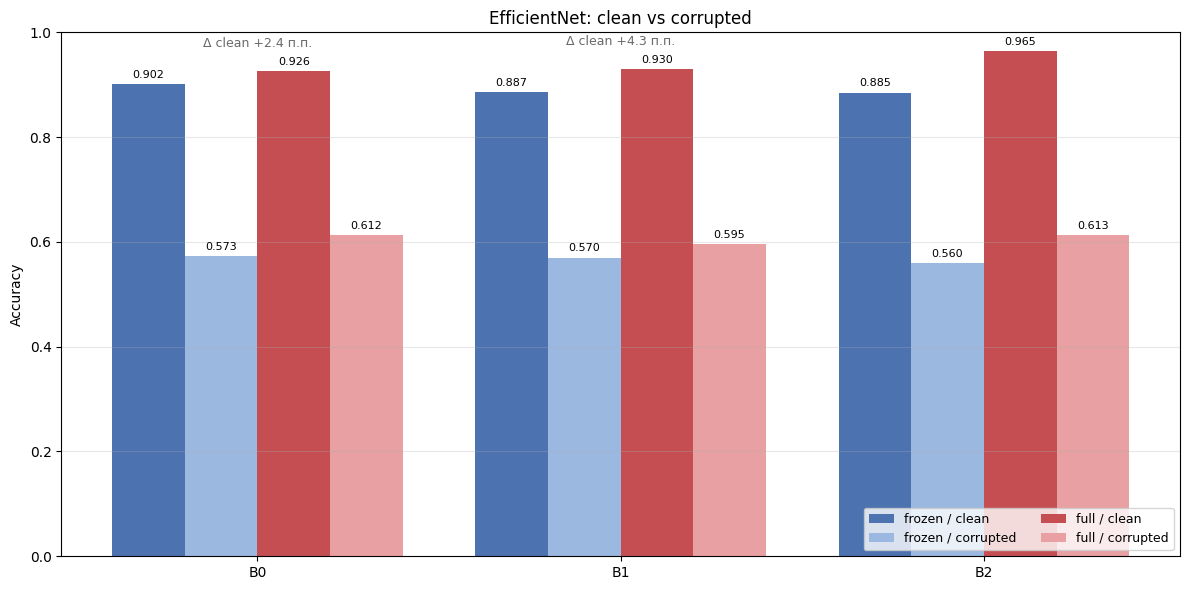

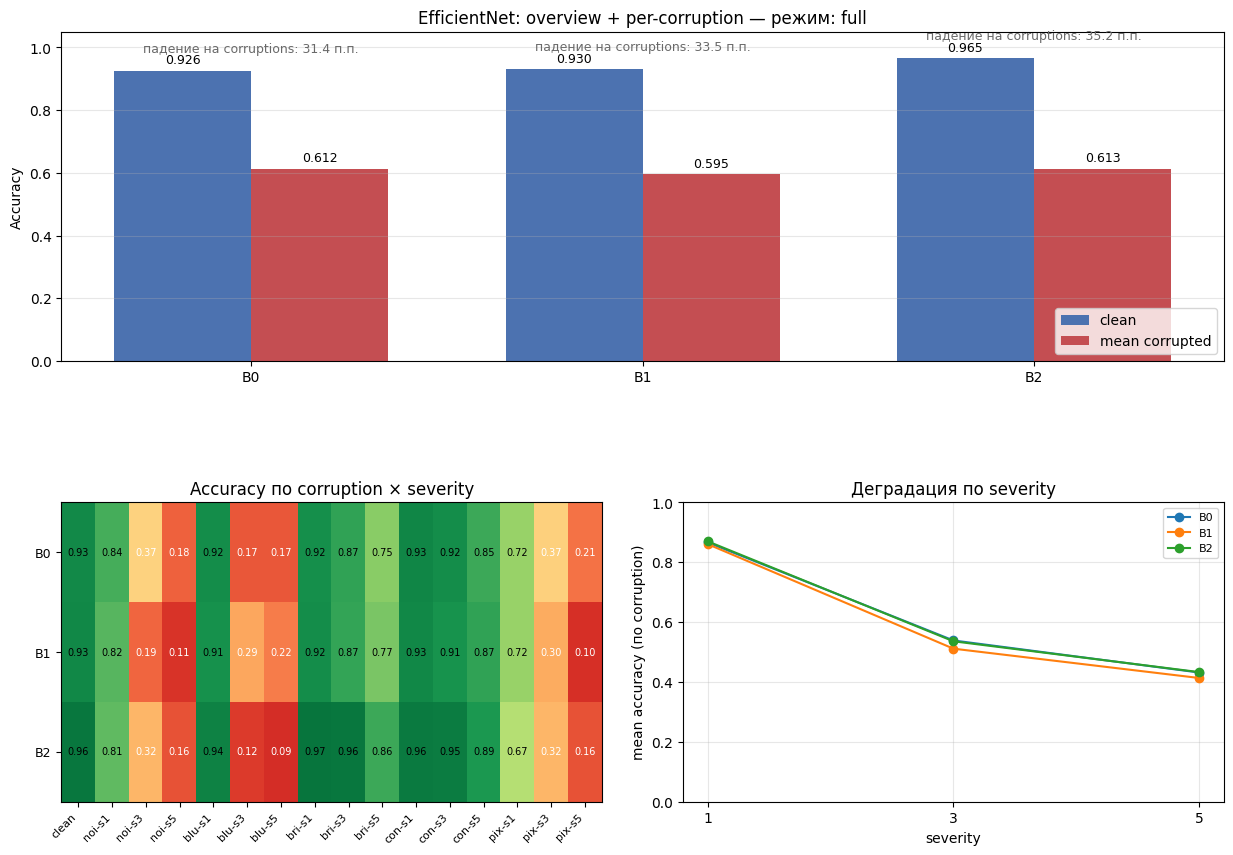

In [18]:
# ============================================================================
# Расширенная панель: bar (обзор) + heatmap (per-corruption)
# ============================================================================
CORRUPTIONS_ORDER = ["noise", "blur", "brightness", "contrast", "pixelate"]
SEVERITIES = [1, 3, 5]


def _per_corruption_matrix(rows, kind="full"):
    """
    Возвращает:
        names        — список моделей
        col_labels   — подписи столбцов (corruption × severity + clean)
        mat          — матрица [model, col] со значениями accuracy
    """
    names = [r["name"] for r in rows]
    col_labels = ["clean"]
    for c in CORRUPTIONS_ORDER:
        for s in SEVERITIES:
            col_labels.append(f"{c[:3]}-s{s}")

    mat = np.full((len(names), len(col_labels)), np.nan)
    for i, r in enumerate(rows):
        rep = None
        # re-load raw report to have per-key access
        # rows хранит только clean/corr — подгрузим нужный отчёт
        run = f"effnet_{r['name'].lower()}"
        p = RUNS_DIR / run / f"report_{kind}.pkl"
        if p.exists():
            with open(p, "rb") as f:
                rep = pickle.load(f)
        if rep is None:
            continue
        mat[i, 0] = rep["clean"][0]
        for j, c in enumerate(CORRUPTIONS_ORDER, start=1):
            for k, s in enumerate(SEVERITIES):
                col = 1 + (j - 1) * len(SEVERITIES) + k
                mat[i, col] = rep[(c, s)][0]
    return names, col_labels, mat


def plot_full_dashboard(rows, kind="full",
                        title="EfficientNet: overview + per-corruption"):
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1.0],
                          hspace=0.45, wspace=0.15)

    # ---------- верх: bar-обзор (только выбранный kind) ----------
    ax_bar = fig.add_subplot(gs[0, :])
    labels = [r["name"] for r in rows]
    n = len(labels)
    x = np.arange(n)
    w = 0.35

    clean = [r[kind]["clean"] if r[kind] else 0 for r in rows]
    corr  = [r[kind]["corr"]  if r[kind] else 0 for r in rows]

    b1 = ax_bar.bar(x - w/2, clean, w, label="clean", color="#4c72b0")
    b2 = ax_bar.bar(x + w/2, corr,  w, label="mean corrupted", color="#c44e52")

    for series in (b1, b2):
        for rect in series:
            h = rect.get_height()
            if h <= 0:
                continue
            ax_bar.annotate(f"{h:.3f}",
                            xy=(rect.get_x() + rect.get_width()/2, h),
                            xytext=(0, 3), textcoords="offset points",
                            ha="center", va="bottom", fontsize=9)

    # подписи над группами: разница clean − corrupted
    for i, r in enumerate(rows):
        d = r[kind]
        if d is None:
            continue
        drop = d["clean"] - d["corr"]
        y = max(clean[i], corr[i]) + 0.05
        ax_bar.annotate(f"падение на corruptions: {drop*100:.1f} п.п.",
                        xy=(x[i], y), ha="center", va="bottom",
                        fontsize=9, color="dimgray")

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(labels)
    ax_bar.set_ylim(0, 1.05)
    ax_bar.set_ylabel("Accuracy")
    ax_bar.set_title(f"{title} — режим: {kind}")
    ax_bar.legend(loc="lower right")
    ax_bar.grid(axis="y", alpha=0.3)

    # ---------- низ-лево: heatmap по corruption × severity ----------
    ax_hm = fig.add_subplot(gs[1, 0])
    names, cols, mat = _per_corruption_matrix(rows, kind=kind)
    im = ax_hm.imshow(mat, cmap="RdYlGn", vmin=0.0, vmax=1.0, aspect="auto")
    ax_hm.set_xticks(range(len(cols)))
    ax_hm.set_xticklabels(cols, rotation=45, ha="right", fontsize=8)
    ax_hm.set_yticks(range(len(names)))
    ax_hm.set_yticklabels(names, fontsize=9)
    ax_hm.set_title("Accuracy по corruption × severity")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if np.isnan(v):
                continue
            ax_hm.text(j, i, f"{v:.2f}", ha="center", va="center",
                       fontsize=7,
                       color="black" if v > 0.5 else "white")

    # ---------- низ-право: profile по severity (усреднённый по corruption) ----------
    ax_line = fig.add_subplot(gs[1, 1])
    for i, r in enumerate(rows):
        run = f"effnet_{r['name'].lower()}"
        p = RUNS_DIR / run / f"report_{kind}.pkl"
        if not p.exists():
            continue
        with open(p, "rb") as f:
            rep = pickle.load(f)
        ys = []
        for s in SEVERITIES:
            vals = [rep[(c, s)][0] for c in CORRUPTIONS_ORDER]
            ys.append(float(np.mean(vals)))
        ax_line.plot(SEVERITIES, ys, marker="o", label=r["name"])
    ax_line.set_xticks(SEVERITIES)
    ax_line.set_xlabel("severity")
    ax_line.set_ylabel("mean accuracy (по corruption)")
    ax_line.set_ylim(0, 1.0)
    ax_line.set_title("Деградация по severity")
    ax_line.legend(fontsize=8)
    ax_line.grid(alpha=0.3)

    plt.show()


# ---- запуск ----
rows = _collect()
plot_overview(rows)                              # вариант 1
plot_full_dashboard(rows, kind="full")           # вариант 2 (для full-FT)
# plot_full_dashboard(rows, kind="frozen")       # то же для frozen, если нужно